In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures


In [2]:
#open dataset 
df_unemployment = pd.read_csv("UnemploymentRate.csv")
df_unemployment

,Month,Total,"Men, 20 years and over","Women, 20 years and over",16 to 19 years old,White,Black or African American,Asian,Hispanic or Latino
0,Mar-06,4.7,4.1,4.2,16.1,4.0,9.5,3.5,5.2
1,Apr-06,4.7,4.2,4.3,14.6,4.1,9.4,3.9,5.5
2,May-06,4.6,4.2,4.1,14.0,4.1,8.7,3.3,5.0
3,Jun-06,4.6,4.0,4.1,15.8,4.1,8.9,3.1,5.2
4,Jul-06,4.7,4.1,4.2,15.9,4.1,9.5,2.4,5.2
...,...,...,...,...,...,...,...,...,...
236,Nov-25,4.5,4.1,4.1,16.3,3.9,8.2,3.6,5.0
237,Dec-25,4.4,3.9,3.9,15.7,3.8,7.5,3.6,4.9
238,Jan-26,4.3,3.8,4.1,13.6,3.7,7.3,4.2,4.9
239,Feb-26,4.4,4.0,4.1,14.9,3.7,7.7,4.8,5.2


In [3]:
#check for missing values 
missing_val = df_unemployment.isna().sum()
missing_val

Month                        0
Total                        1
Men, 20 years and over       1
Women, 20 years and over     1
16 to 19 years old           1
White                        1
Black or African American    1
Asian                        1
Hispanic or Latino           1
dtype: int64

In [4]:
#transform all functions into numeric or datetime 
df_unemployment["Total"] = pd.to_numeric(df_unemployment["Total"], errors="coerce")
df_unemployment["Men, 20 years and over"] = pd.to_numeric(df_unemployment["Men, 20 years and over"], errors="coerce")
df_unemployment["Women, 20 years and over"] = pd.to_numeric(df_unemployment["Women, 20 years and over"], errors="coerce")
df_unemployment["16 to 19 years old"] = pd.to_numeric(df_unemployment["16 to 19 years old"], errors="coerce")
df_unemployment["White"] = pd.to_numeric(df_unemployment["White"], errors="coerce")
df_unemployment["Black or African American"] = pd.to_numeric(df_unemployment["Black or African American"], errors="coerce")
df_unemployment["Asian"] = pd.to_numeric(df_unemployment["Asian"], errors="coerce")
df_unemployment["Hispanic or Latino"] = pd.to_numeric(df_unemployment["Hispanic or Latino"], errors="coerce")
df_unemployment["Month"] = pd.to_datetime(df_unemployment["Month"],format = '%b-%y')

In [5]:
df_unemployment.describe() #description of the dataset

,Month,Total,"Men, 20 years and over","Women, 20 years and over",16 to 19 years old,White,Black or African American,Asian,Hispanic or Latino
count,241,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000,240.000000
mean,2016-03-01 13:08:42.821576704,5.773333,5.478750,5.142500,17.067083,5.134583,9.724167,4.578750,7.204167
min,2006-03-01 00:00:00,3.400000,3.200000,3.100000,9.400000,3.000000,4.800000,2.000000,3.900000
25%,2011-03-01 00:00:00,4.100000,3.800000,3.700000,12.900000,3.600000,6.700000,3.100000,5.000000
50%,2016-03-01 00:00:00,4.900000,4.450000,4.300000,15.850000,4.250000,8.600000,3.850000,5.900000
75%,2021-03-01 00:00:00,7.350000,7.025000,6.425000,21.325000,6.625000,12.800000,5.725000,9.225000
max,2026-03-01 00:00:00,14.800000,13.000000,15.500000,32.800000,14.200000,16.900000,15.000000,18.900000
std,NaN,2.163359,2.213464,1.943045,5.143005,1.998350,3.505393,2.060753,2.942913


In [6]:
#check for datatypes 
print(df_unemployment.dtypes)

Month                        datetime64[ns]
Total                               float64
Men, 20 years and over              float64
Women, 20 years and over            float64
16 to 19 years old                  float64
White                               float64
Black or African American           float64
Asian                               float64
Hispanic or Latino                  float64
dtype: object


In [7]:
#drop unused columns 
df_unemployment=df_unemployment.drop(columns=["16 to 19 years old"])
df_unemployment_dates = df_unemployment.copy()

In [8]:
#Only ckeep year
df_unemployment["Month"]= df_unemployment["Month"].dt.year
df_unemployment.rename(columns={'Month':'Year'} ,inplace=True)
#group year by the mean employment rate 
df_unemployment = round(df_unemployment.groupby("Year").mean(),3)
df_unemployment

,Total,"Men, 20 years and over","Women, 20 years and over",White,Black or African American,Asian,Hispanic or Latino
Year,,,,,,,
2006,4.580,4.020,4.100,4.020,8.900,3.060,5.180
2007,4.617,4.150,4.025,4.117,8.258,3.233,5.642
2008,5.800,5.475,4.883,5.192,10.100,3.950,7.617
2009,9.283,9.608,7.483,8.492,14.783,7.292,12.083
2010,9.608,9.817,8.033,8.717,15.958,7.500,12.492
2011,8.933,8.700,7.917,7.933,15.825,7.017,11.492
2012,8.075,7.525,7.342,7.192,13.825,5.900,10.317
2013,7.358,6.975,6.533,6.508,13.067,5.225,9.108
2014,6.158,5.708,5.592,5.300,11.342,4.983,7.400


In [9]:
#separate datasets from gender and race 
df_unemployment_split_gender=df_unemployment.drop(columns=["White", "Black or African American", "Asian", "Hispanic or Latino"])
df_unemployment_split_race=df_unemployment.drop(columns=["Men, 20 years and over",	"Women, 20 years and over"])
df_unemployment_split_gender.to_csv("Unemployment Rate Gender") #save datasets
df_unemployment_split_race.to_csv("Unemployment Rate Race")

In [10]:
#open new edited datasets that have been unpivoted through power query 
df_unemployment_race = pd.read_csv("Unemployment Rates by Race.csv")
df_unemployment_rate_gender=pd.read_csv("Unemployment Rates by Gender.csv")
#transform datatypes 
df_unemployment_race["Unemployment Rate"] = pd.to_numeric(df_unemployment_race["Unemployment Rate"], errors="coerce")
df_unemployment_race["Year"] = pd.to_numeric(df_unemployment_race['Year'], errors="coerce")
df_unemployment_rate_gender["Unemployment Rate"] = pd.to_numeric(df_unemployment_rate_gender["Unemployment Rate"], errors="coerce")
df_unemployment_rate_gender["Year"] = pd.to_numeric(df_unemployment_rate_gender['Year'], errors="coerce")

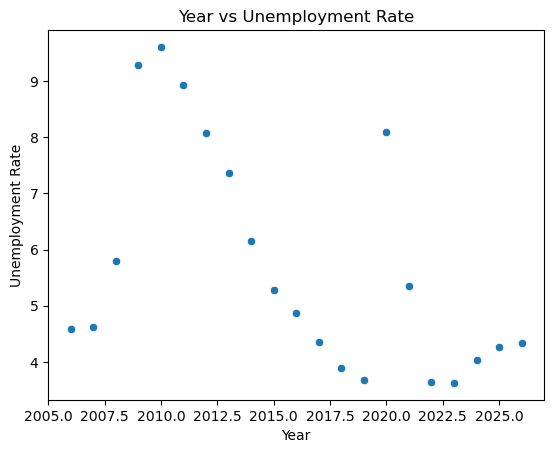

In [11]:
#scatter plot of Unemployment rate against Year 
sns.scatterplot(x="Year", y="Total", data=df_unemployment)
plt.title("Year vs Unemployment Rate")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.show()

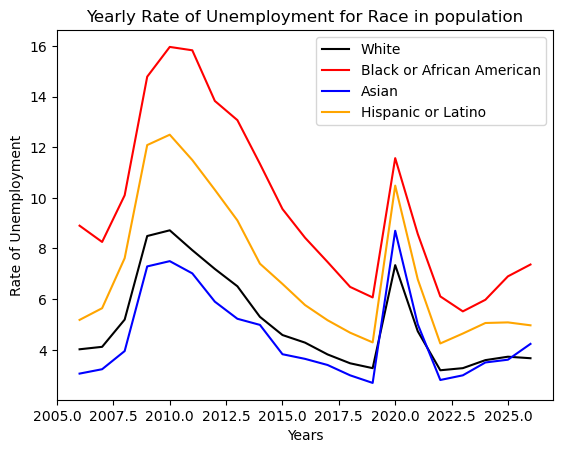

In [12]:
#line plots of respective races/ethinicities with year 
sns.lineplot(x="Year", y="White", data=df_unemployment, color = "black", label ="White")

sns.lineplot(x="Year", y="Black or African American", data=df_unemployment, color = "red", label = "Black or African American")

sns.lineplot(x="Year", y="Asian", data=df_unemployment, color = "blue", label = "Asian")

sns.lineplot(x="Year", y="Hispanic or Latino", data=df_unemployment, color = "orange", label = "Hispanic or Latino")
plt.title("Yearly Rate of Unemployment for Race in population")
plt.xlabel("Years")
plt.ylabel("Rate of Unemployment")
plt.legend()
plt.show()

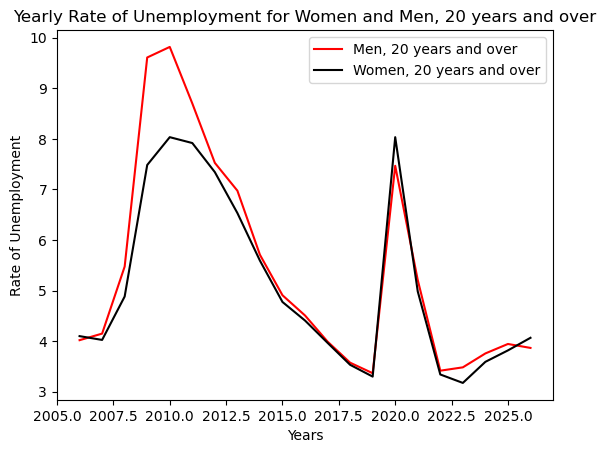

,Year,Total,"Men, 20 years and over","Women, 20 years and over",White,Black or African American,Asian,Hispanic or Latino
0,2006,4.580,4.020,4.100,4.020,8.900,3.060,5.180
1,2007,4.617,4.150,4.025,4.117,8.258,3.233,5.642
2,2008,5.800,5.475,4.883,5.192,10.100,3.950,7.617
3,2009,9.283,9.608,7.483,8.492,14.783,7.292,12.083
4,2010,9.608,9.817,8.033,8.717,15.958,7.500,12.492
5,2011,8.933,8.700,7.917,7.933,15.825,7.017,11.492
6,2012,8.075,7.525,7.342,7.192,13.825,5.900,10.317
7,2013,7.358,6.975,6.533,6.508,13.067,5.225,9.108
8,2014,6.158,5.708,5.592,5.300,11.342,4.983,7.400
9,2015,5.275,4.908,4.775,4.583,9.558,3.825,6.600


In [89]:
#lineplot of gender and year 
sns.lineplot(x="Year", y="Men, 20 years and over", data=df_unemployment, color = "red", label = "Men, 20 years and over")


sns.lineplot(x="Year", y="Women, 20 years and over", data=df_unemployment, color = "black", label="Women, 20 years and over")
plt.title("Yearly Rate of Unemployment for Women and Men, 20 years and over")
plt.xlabel("Years")
plt.ylabel("Rate of Unemployment")
plt.legend()
plt.show()



Text(0.5, 1.0, 'Unemployment Rate by Race')

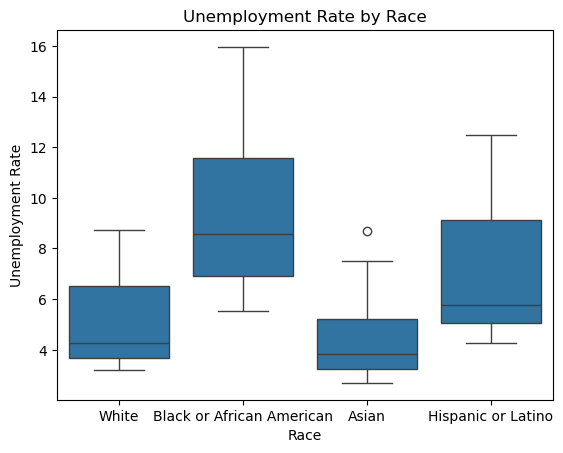

In [90]:
#boxplot by race 
ax = sns.boxplot(data=df_unemployment_race, x="Race", y="Unemployment Rate")
ax.set_title("Unemployment Rate by Race")

Text(0.5, 1.0, 'Unemployment Rate by Gender')

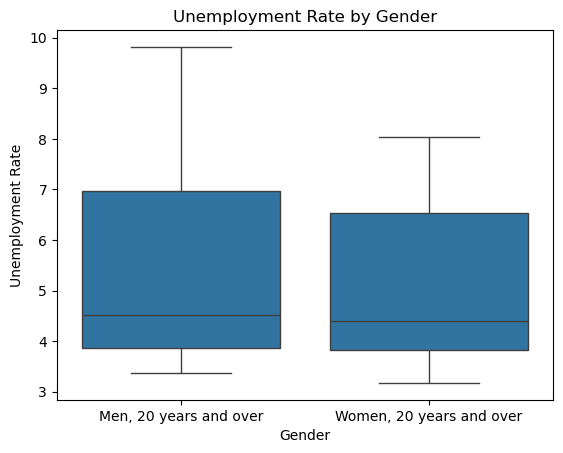

In [91]:
#unemployment rate boxplot by gender
ax = sns.boxplot(data=df_unemployment_rate_gender, x="Gender", y="Unemployment Rate")
ax.set_title("Unemployment Rate by Gender")

In [92]:
#turn categories into dummies to perform regression
df_unemployment_race = pd.get_dummies(df_unemployment_race, columns=["Race"], dtype='int')

In [93]:
#drop white as reference group
df_unemployment_race.drop(columns="Race_White")


,Year,Total,Unemployment Rate,Race_Asian,Race_Black or African American,Race_Hispanic or Latino
0,2006,4.580,4.020,0,0,0
1,2006,4.580,8.900,0,1,0
2,2006,4.580,3.060,1,0,0
3,2006,4.580,5.180,0,0,1
4,2007,4.617,4.117,0,0,0
...,...,...,...,...,...,...
79,2025,4.264,5.082,0,0,1
80,2026,4.333,3.667,0,0,0
81,2026,4.333,7.367,0,1,0
82,2026,4.333,4.233,1,0,0


In [94]:
#keep any year after 2020 for analysis 
df_unemployment_race = df_unemployment_race.loc[(df_unemployment_race['Year'] >= 2020)]
df_unemployment_rate_gender = df_unemployment_rate_gender.loc[(df_unemployment_rate_gender['Year'] >= 2020)]

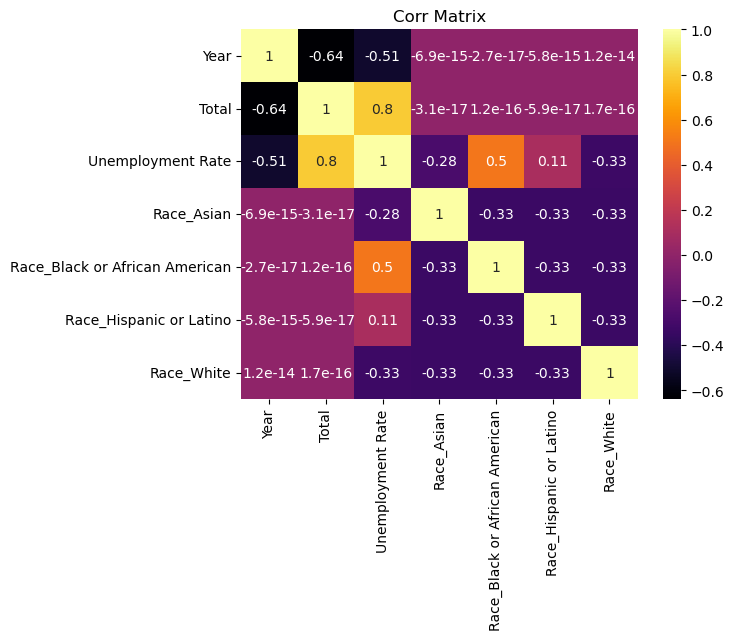

In [95]:
#find the correlation matrix between dummy variables for race
corr_matrix=df_unemployment_race.corr(numeric_only=True)

ax = sns.heatmap(corr_matrix, annot=True, cmap="inferno")
ax.set_title("Corr Matrix")
plt.show()

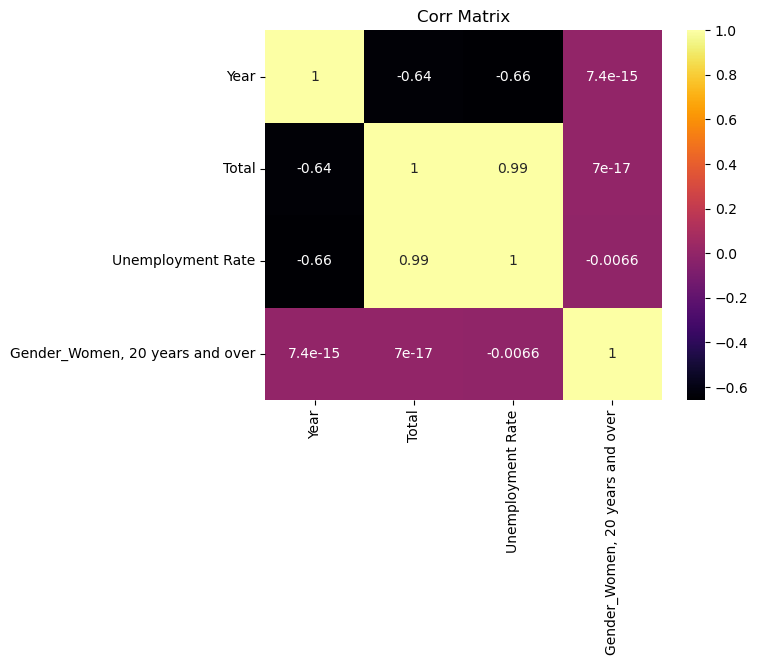

In [96]:
#find the correlation matrix between dummy variables for gender
df_unemployment_rate_gender = pd.get_dummies(df_unemployment_rate_gender, columns=["Gender"],drop_first=True, dtype='int')
corr_matrix=df_unemployment_rate_gender.corr(numeric_only=True)

ax = sns.heatmap(corr_matrix, annot=True, cmap="inferno")
ax.set_title("Corr Matrix")
plt.show()

In [134]:
#linear Regression for Race Dataset
X=df_unemployment_race[["Race_Asian","Race_Black or African American","Race_Hispanic or Latino", "Year"]]
y=df_unemployment_race["Unemployment Rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.33, 
    random_state = 40,
    shuffle = True
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_, "\nCoefficients:", model.coef_)



Intercept: 798.414165844403 
Coefficients: [-0.13909298  3.55511784  1.03455712 -0.39258918]


In [144]:
#polynomial regression for race dataset
poly = PolynomialFeatures(degree=2, include_bias = False)
X_train_poly = poly.fit_transform(X_train)

poly_model=LinearRegression()
poly_model.fit(X_train_poly,y_train)

print("Intercept:", poly_model.intercept_, "\nCoefficients:", poly_model.coef_)

Intercept: 1434474.4560333553 
Coefficients: [-1.99941372e+02  6.41877919e+01 -2.25642700e+02 -1.41759523e+03
 -1.99941372e+02  0.00000000e+00 -1.13686838e-13  1.97783239e-01
  6.41877916e+01  0.00000000e+00 -6.17301773e-02 -2.25642700e+02
  2.23925707e-01  3.50229205e-01]


In [146]:
#mae,mse,rmse,r2 for polynomial regression for race dataset
y_test_pred = poly_model.predict(poly.transform(X_test))
mae = mean_absolute_error(y_test,y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Race Logistic Regression: \nMAE:", mae, "\nMSE:", mse, "\nRMSE:", rmse,"\nR2:",r2)

Race Logistic Regression: 
MAE: 1.0250218170825394 
MSE: 1.3648549545920476 
RMSE: 1.1682700692014871 
R2: 0.7327547053128647


In [126]:
#mae,mse,rmse,r2 for linear regression for race dataset
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

mae, mse, rmse, r2
print("Race Linear Regression: \nMAE:", mae, "\nMSE:", mse, "\nRMSE:", rmse,"\nR2:",r2)

Race Linear Regression: 
MAE: 1.31553538899428 
MSE: 3.6018535719492824 
RMSE: 1.8978549923398473 
R2: 0.2947394036143498


In [140]:
#Linear regression for gender
X_g=df_unemployment_rate_gender[["Gender_Women, 20 years and over", "Year"]]
y_g=df_unemployment_rate_gender["Unemployment Rate"]

X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(
    X_g,y_g,
    test_size = 0.44, 
    random_state = 49,
    shuffle = True
)
X_g_train.shape, X_g_test.shape, y_g_train.shape, y_g_test.shape

model_g = LinearRegression()
model_g.fit(X_g_train, y_g_train)


print("Intercept:", model_g.intercept_, "\nCoefficients:", model_g.coef_)

Intercept: 330.1709500000001 
Coefficients: [-0.4952  -0.16125]


In [142]:
#polynomial regression for gender
poly_g = PolynomialFeatures(degree=3, include_bias = False)
X_train_g = poly_g.fit_transform(X_g_train)

poly_model_g=LinearRegression()
poly_model_g.fit(X_train_g,y_g_train)

print("Intercept:", poly_model_g.intercept_, "\nCoefficients:", poly_model_g.coef_)

Intercept: 1343160328.5983255 
Coefficients: [-2.29296207e+03 -1.99123305e+06  2.41856507e-03  1.15672024e+00
  9.83999686e+02  2.80624436e-03  1.15652582e+00 -5.83242502e-04
 -1.62086357e-01]


In [130]:
#mae,mse,rmse,r2 for polynomial regression for gender dataset
y_test_polyg = poly_model_g.predict(poly_g.transform(X_g_test))
mae = mean_absolute_error(y_g_test,y_test_polyg)
mse = mean_squared_error(y_g_test, y_test_polyg)
rmse = np.sqrt(mse)
r2 = r2_score(y_g_test, y_test_polyg)
print("Gender Logistic Regression: \nMAE:", mae, "\nMSE:", mse, "\nRMSE:", rmse,"\nR2:",r2)

Gender Logistic Regression: 
MAE: 0.9282099511282785 
MSE: 1.4381510068996977 
RMSE: 1.1992293387420514 
R2: 0.5453694432289773


In [150]:
#mae,mse,rmse,r2 for linear regression for gender dataset
y_pred_g = model_g.predict(X_g_test)
mae = mean_absolute_error(y_g_test,y_pred_g)
mse = mean_squared_error(y_g_test, y_pred_g)
rmse = np.sqrt(mse)
r2 = r2_score(y_g_test, y_pred_g)

mae, mse, rmse, r2
print("Race Linear Regression: \nMAE:", mae, "\nMSE:", mse, "\nRMSE:", rmse,"\nR2:",r2)

Race Linear Regression: 
MAE: 1.5335142857142932 
MSE: 4.154328832857199 
RMSE: 2.0382170720649944 
R2: -0.31327296037105645
